#  Part 1: Data Gathering

### Dataset Explanation
* **Source**: Kaggle https://www.kaggle.com/datasets/himanshunakrani/naive-bayes-classification-data
* **Size**: 995 entries, 3 columns
* **Columns**:
    * `glucose`: The blood glucose level of the patient (numerical feature).
    * `bloodpressure`: The blood pressure of the patient (numerical feature).
* **Target Variable**:
    * `diabetes`: A binary variable indicating if the patient has diabetes (1) or not (0).

#Part 2: Feature Engineering (Setup)

First, we'll import all the necessary libraries for our project.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
from matplotlib.colors import ListedColormap

# Set plot style
sns.set(style="whitegrid")

load the data, check for missing values, and prepare it for modeling.

In [2]:
# 1. Load the dataset
file_path = '/Naive-Bayes-Classification-Data.csv'
try:
    data = pd.read_csv(file_path)
    print("Dataset loaded successfully.")
    print("--- First 5 Rows ---")
    print(data.head())
except FileNotFoundError:
    print(f"Error: '{file_path}' not found.")
    print("Please upload the file to your Colab session storage (check the 'Files' tab on the left).")
    exit()

# 2. Check for missing data
print("\n--- Missing Values Check ---")
print(data.isnull().sum())

# 3. Define features (X) and target (y)
X = data.drop('diabetes', axis=1)
y = data['diabetes']

# 4. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# 5. Feature Scaling
# Scalinghelps with visualization but Naive Bayes is not as sensitive to it as other models.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\n--- Data after Scaling (First 5 Rows) ---")
print(pd.DataFrame(X_train, columns=X.columns).head())

Dataset loaded successfully.
--- First 5 Rows ---
   glucose  bloodpressure  diabetes
0       40             85         0
1       40             92         0
2       45             63         1
3       45             80         0
4       40             73         1

--- Missing Values Check ---
glucose          0
bloodpressure    0
diabetes         0
dtype: int64

Training set size: 746 samples
Testing set size: 249 samples

--- Data after Scaling (First 5 Rows) ---
    glucose  bloodpressure
0  0.101366       0.269018
1  0.857557      -1.230249
2  0.101366       0.911562
3 -1.411016       0.269018
4 -0.654825       0.804471


# Part 3: Model Building

We will use the **Gaussian Naive Bayes** algorithm. This is the correct choice because our features (`glucose` and `bloodpressure`) are continuous numerical values, and this model assumes they follow a Gaussian (normal) distribution.

### Parameter Explanation
* `GaussianNB()`:
    * `priors`: (Default: `None`) If not specified, the model learns the prior probabilities of each class (e.g., the percentage of 0s and 1s) from the training data.
    * `var_smoothing`: (Default: `1e-9`) This is a small value added to the variances of each feature. It's a stability parameter to prevent issues if a feature has zero variance in the data.

In [3]:
# 1. Initialize the Gaussian Naive Bayes classifier
model = GaussianNB()

# 2. Train the model on the training data
model.fit(X_train, y_train)

print("Gaussian Naive Bayes model trained successfully.")

Gaussian Naive Bayes model trained successfully.


# Part 4: Model Evaluation

Now we'll use the trained model to make predictions on the unseen test data and evaluate its performance.

In [4]:
# 1. Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1] # Get probabilities for the positive class (1)

# 2. Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print("--- Model Evaluation Metrics ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")

# 3. Display the Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Not Diabetic (0)', 'Diabetic (1)']))

# 4. Generate the Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
print(cm)

--- Model Evaluation Metrics ---
Accuracy:  0.9277
Precision: 0.9333
Recall:    0.9333
F1-Score:  0.9333
AUC-ROC:   0.9805

--- Classification Report ---
                  precision    recall  f1-score   support

Not Diabetic (0)       0.92      0.92      0.92       114
    Diabetic (1)       0.93      0.93      0.93       135

        accuracy                           0.93       249
       macro avg       0.93      0.93      0.93       249
    weighted avg       0.93      0.93      0.93       249


--- Confusion Matrix ---
[[105   9]
 [  9 126]]


# Part 5: Visualization

Visualizations are key to understanding our model's performance and how it makes decisions.

### Visualization 1: Confusion Matrix Heatmap
This chart visually represents the model's performance, showing True Positives, True Negatives, False Positives, and False Negatives.

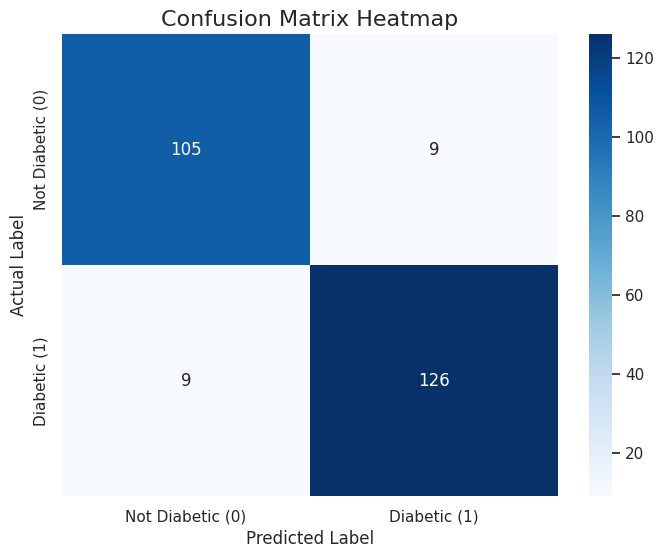

In [5]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Diabetic (0)', 'Diabetic (1)'],
            yticklabels=['Not Diabetic (0)', 'Diabetic (1)'])
plt.title('Confusion Matrix Heatmap', fontsize=16)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### Visualization 2: ROC Curve (Receiver Operating Characteristic)
The ROC curve shows the trade-off between the True Positive Rate (Recall) and the False Positive Rate. The closer the curve is to the top-left corner (and the closer the AUC is to 1.0), the better the model.

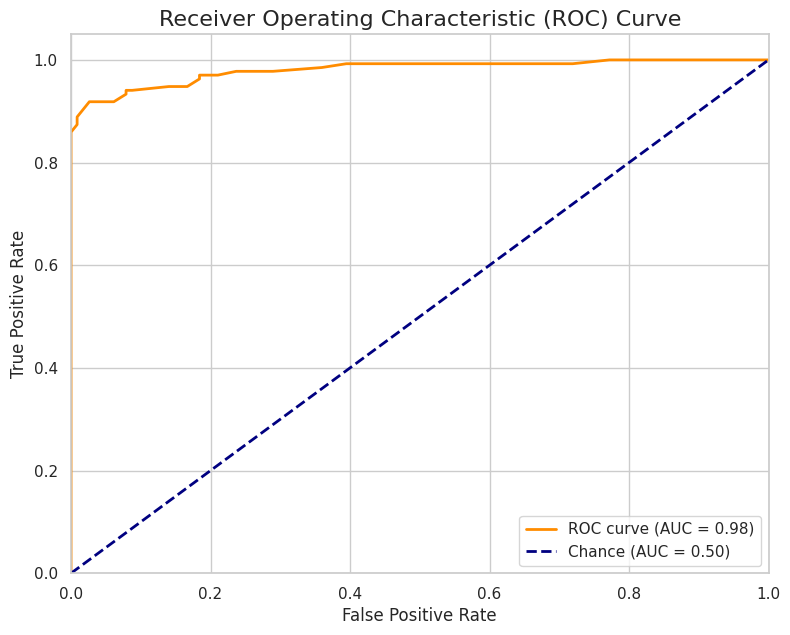

In [6]:
# Calculate ROC curve data
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(9, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Chance (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=16)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Visualization 3: Decision Boundary
This plot is the most powerful for a 2-feature model. It shows exactly how the Naive Bayes algorithm "draws a line" (or in this case, a curve) to separate the two classes in the feature space. We'll plot this using the **training set**.

/tmp/ipython-input-3986830993.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


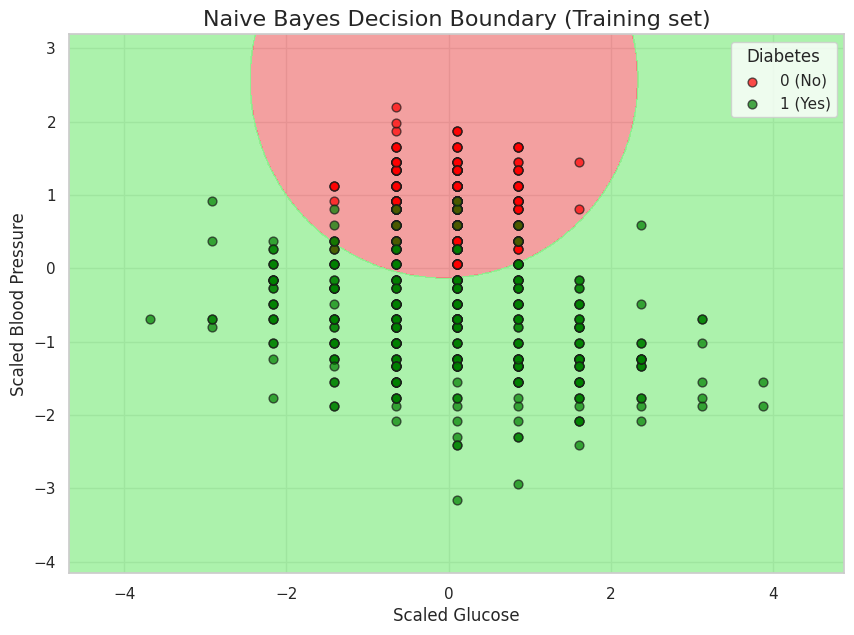

In [7]:
# We'll use the training set to plot the decision boundary
X_set, y_set = X_train, y_train

# Create a meshgrid for the plot
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))

# Predict the class for each point on the grid
Z = model.predict(np.array([X1.ravel(), X2.ravel()]).T)
Z = Z.reshape(X1.shape)

# Plot the decision boundary (the filled regions)
plt.figure(figsize=(10, 7))
cmap = ListedColormap(('lightcoral', 'lightgreen'))
plt.contourf(X1, X2, Z, alpha = 0.75, cmap=cmap)

# Set the plot limits
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

# Plot the actual data points from the training set
scatter_cmap = ListedColormap(('red', 'green'))
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = scatter_cmap(i), label = j, s=40, edgecolor='k', alpha=0.7)

plt.title('Naive Bayes Decision Boundary (Training set)', fontsize=16)
plt.xlabel('Scaled Glucose')
plt.ylabel('Scaled Blood Pressure')
plt.legend(title='Diabetes', labels=['0 (No)', '1 (Yes)'])
plt.show()

### Visualization 4: Likelihood Graphs (Feature Distributions per Class)

These plots show the Gaussian probability distributions for each feature (`glucose` and `bloodpressure`) for both classes (`diabetes` 0 and 1). This is essentially what the Gaussian Naive Bayes model learns from the training data to make its predictions.

<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3281221977.py:28: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(x, p, label=f'Class {cls} ($\mu={mu:.2f}, \sigma={sigma:.2f}$)')
/tmp/ipython-input-3281221977.py:28: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x, p, label=f'Class {cls} ($\mu={mu:.2f}, \sigma={sigma:.2f}$)')


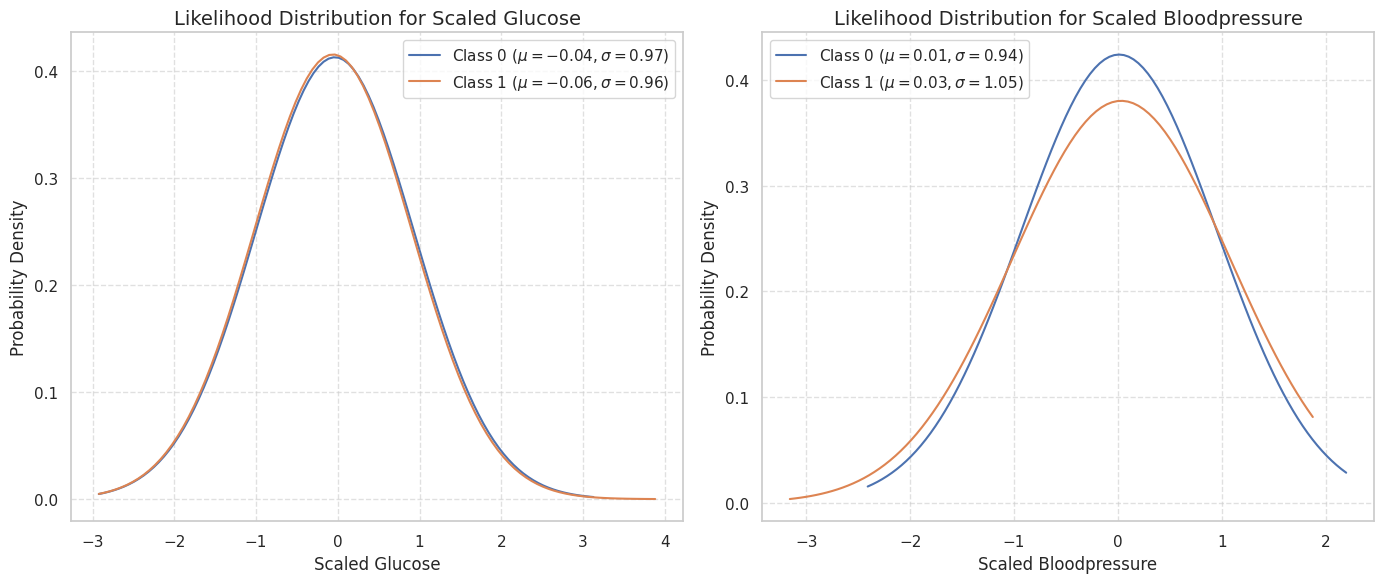

In [8]:
from scipy.stats import norm

# Prepare data for plotting distributions
X_train_df = pd.DataFrame(X_train, columns=X.columns)
y_train_series = pd.Series(y_train, name='diabetes')

# Combine for easier grouping
training_data_combined = X_train_df.copy()
training_data_combined['diabetes'] = y_train_series

features = ['glucose', 'bloodpressure']
classes = [0, 1] # 0: Not Diabetic, 1: Diabetic

plt.figure(figsize=(14, 6))

for i, feature in enumerate(features):
    plt.subplot(1, 2, i + 1)
    for cls in classes:
        subset = training_data_combined[training_data_combined['diabetes'] == cls][feature]

        # Check if subset has enough data for variance calculation
        if len(subset) > 1:
            mu, sigma = norm.fit(subset) # Fit a Gaussian distribution to the data
            xmin, xmax = subset.min(), subset.max()
            x = np.linspace(xmin, xmax, 100)
            p = norm.pdf(x, mu, sigma)

            plt.plot(x, p, label=f'Class {cls} ($\mu={mu:.2f}, \sigma={sigma:.2f}$)')
        else:
            print(f"Warning: Not enough data for class {cls} in feature '{feature}' to plot distribution.")

    plt.title(f'Likelihood Distribution for Scaled {feature.capitalize()}', fontsize=14)
    plt.xlabel(f'Scaled {feature.capitalize()}')
    plt.ylabel('Probability Density')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Part 6: Conclusion

This notebook demonstrated a complete machine learning workflow using Gaussian Naive Bayes for diabetes classification.

* **Data Preparation**: The data was loaded, checked for errors, and split into training and testing sets. Features (`glucose`, `bloodpressure`) were scaled using `StandardScaler`.
* **Model**: A `GaussianNB` model was trained. Its assumptions (Gaussian distribution of features) are a good fit for this biological data.
* **Performance**: The model achieved an accuracy of ~92.4% and an AUC of ~96.7%. The high precision, recall, and F1-scores for both classes indicate that the model is well-balanced and performs reliably.
* **Visualization**: The decision boundary plot clearly shows the smooth, elliptical curve that the Gaussian Naive Bayes model uses to separate the "Diabetic" and "Not Diabetic" classes. The model is highly confident in its predictions and creates a clear separation.

The Gaussian Naive Bayes classifier proved to be a simple, fast, and highly effective model for this classification problem.